In [1]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
import math
import numpy as np
import random
import requests
from time import sleep
from IPython.display import clear_output
from itertools import zip_longest

In [2]:
file_id = "1bEpF3iwAnaorj-Xl870gB62uqro5arQ3"
url = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=xlsx"
response = requests.get(url)

with open("airplane_data.xlsx", "wb") as f:
    f.write(response.content)

In [3]:
# method to read data from excel file
def read_plane_data(file_name):
    df_planes = pd.read_excel(file_name)
    return df_planes

df = read_plane_data('airplane_data.xlsx')

print('Here are your plane choices:')
print(df['aircraft_type'])

Here are your plane choices:
0                        A220-300
1              Bombardier CRJ-900
2                Beechcraft 1900D
3            Boeing 737-300 (733)
4      Airbus A319 (319) Layout 1
5    Embraer E-175 (E75) Layout 1
6           Airbus A320-200 (320)
7         Boeing 737-700 Layout 2
8                ATR 72-600 (ATR)
9            Boeing 717-200 (717)
Name: aircraft_type, dtype: object


In [4]:
plane_choice = input("Input the number corresponding to the plane you'd like to simulate:")    

Input the number corresponding to the plane you'd like to simulate: 5


In [5]:
plane_type = df.loc[int(plane_choice)].at['aircraft_type']
print('You selected:', plane_type)

You selected: Embraer E-175 (E75) Layout 1


In [6]:
def seat_params_info(df, plane_num):
    """
    Gathers seat dimensions (width and pitch) for different cabin classes from the DataFrame.
    Returns a list of tuples for economy, business, and first class.
    """
    # Extract economy class seat width and pitch from the specified row
    seat_width_economy = df.loc[int(plane_num)].at['seat width - economy']
    seat_pitch_economy = df.loc[int(plane_num)].at['seat depth - economy']
    seat_param_economy = seat_width_economy, seat_pitch_economy

    # Extract business class seat width and pitch
    seat_width_business = df.loc[int(plane_num)].at['seat width - business']
    seat_pitch_business = df.loc[int(plane_num)].at['seat depth - business']
    seat_param_business = seat_width_business, seat_pitch_business

    # Extract first class seat width and pitch
    seat_width_1stclass = df.loc[int(plane_num)].at['seat width - first class']
    seat_pitch_1stclass = df.loc[int(plane_num)].at['seat depth - first class']
    seat_param_1stclass = seat_width_1stclass, seat_pitch_1stclass

    # Combine all seat parameter tuples into a single list
    seat_params = [seat_param_economy, seat_param_business, seat_param_1stclass]

    # Return the list of seat parameters
    return seat_params

In [7]:
def num_of_seats_info(df, plane_num):
    """
    Retrieves the total number of seats for economy, business, and first class 
    from the DataFrame for the specified plane, and returns them as a tuple.
    """
    # Extract the total number of economy class seats
    econ = df.at[int(plane_num), "total seats - economy"]
    
    # Extract the total number of business class seats
    bus = df.at[int(plane_num), "total seats - business"]
    
    # Extract the total number of first class seats
    first = df.at[int(plane_num), "total seats - first class"]
    
    # Create a tuple containing seat counts for economy, business, and first class
    num_of_seats = econ, bus, first

    return num_of_seats

In [8]:
def seat_arrange_info(df, plane_num):
    """
    Retrieves seat arrangement details for economy, business, and first class from the DataFrame.
    Returns a list containing the seat arrangements for each cabin class.
    """
    # Get the seat arrangement for economy class from the specified row
    seat_arrange_econ = df.loc[int(plane_num)].at['seat arrangement - economy']

    # Get the seat arrangement for business class from the specified row
    seat_arrange_bus = df.loc[int(plane_num)].at['seat arrangement - business']
    
    # Get the seat arrangement for first class from the specified row
    seat_arrange_1st = df.loc[int(plane_num)].at['seat arrangement - first class']
    
    # Combine all retrieved arrangements into a list
    seat_arrange = [seat_arrange_econ, seat_arrange_bus, seat_arrange_1st]

    return seat_arrange

In [9]:
class Seat:
    def __init__(self, seat_label, class_type, coords, side_of_plane, width):
        # Full seat label string (e.g., "12A")
        self.seat_label = seat_label
        # Extract the letter from the seat label (e.g., "A")
        self.letter = seat_label[-1]
        # Extract the row number from the seat label (e.g., 12)
        self.row = int(seat_label[:-1])
        # Class of the seat (e.g., "economy", "business")
        self.class_type = class_type
        # Whether the seat is currently occupied
        self.occupied = False
        # Coordinates for positioning the seat (e.g., for visualization)
        self.x_coord, self.y_coord = coords
        # Fixed depth of the seat (e.g., for layout sizing)
        self.depth = 18
        # Width of the seat (passed as an argument)
        self.width = width
        # Side of the plane the seat is on (e.g., "left" or "right")
        self.side_of_plane = side_of_plane

In [10]:
class Plane:
    def __init__(self, seat_params, num_of_seats, seat_arrange):
        """
        Initialize seat dimensions, number of seats, and arrangement for each class.
        Also sets up plane geometry and generates all seats.
        """
        # Store seat dimensions for each class: (width, legroom)
        self.seat_param_economy = seat_params[0]
        self.seat_param_business = seat_params[1]
        self.seat_param_firstclass = seat_params[2]

        # Store number of seats for each class
        self.num_of_seats_economy = num_of_seats[0]
        self.num_of_seats_business = num_of_seats[1]
        self.num_of_seats_firstclass = num_of_seats[2]

        # Store seat arrangements (e.g., '2 2', '3 3') for each class
        self.seat_arrange_economy = seat_arrange[0]
        self.seat_arrange_business = seat_arrange[1]
        self.seat_arrange_firstclass = seat_arrange[2]

        # Initialize list to store all seat objects
        self.seats = []

        # Set layout dimensions and generate all seats
        self.setup_plane_geometry()
        self.generate_all_seats()

    def generate_seat_labels(self, starting_row, num_of_rows, seats_per_row):
        """
        Generate seat labels (e.g., 1A, 1B, ...) in reverse drawing order.
        Returns a list of strings.
        """
        seat_labels = []
        for row in range(starting_row, num_of_rows + starting_row):
            for seat in range(seats_per_row):
                seat_letter = chr(64 + seats_per_row - seat)  # Assign letters from right to left
                seat_labels.append(f"{row}{seat_letter}")
        return seat_labels[::-1]  # Reverse to match seat drawing order

    def generate_seats(self, seat_type, starting_row, class_type):
        """
        Generate Seat objects for a given class type, starting row, and seat configuration.
        Populates the self.seats list.
        """
        seats_per_col, seats_per_row, num_of_rows, seat_width, leg_room, aisle_gap, start_y = seat_type
        leg_room -= seat_width  # Adjust leg room by subtracting seat width
        seat_depth = 18  # Fixed depth for all seats

        seat_labels = self.generate_seat_labels(starting_row, num_of_rows, seats_per_row)
        label_index = 0

        y = start_y
        padding = 1

        for row in range(num_of_rows):
            x = 0

            # Left side seating
            for seat in range(seats_per_col[0]):
                label = seat_labels[label_index]
                self.seats.append(Seat(label, class_type, (x, y), "left", seat_width))
                label_index += 1
                x += seat_depth + padding

            # Aisle gap
            x += aisle_gap

            # Right side seating
            for seat in range(seats_per_col[2]):
                label = seat_labels[label_index]
                self.seats.append(Seat(label, class_type, (x, y), "right", seat_width))
                label_index += 1
                x += seat_depth + padding

            y += leg_room + seat_width  # Move to next row vertically

    def generate_all_seats(self):
        """
        Clear and regenerate all seats for all cabin classes (first, business, economy).
        Ensures proper vertical stacking using offset and alignment.
        """
        self.seats = []
        y_offset = 0
        starting_row = 1
        reference_params = None  # Used to align aisles across classes

        # Grouping class-specific data for iteration
        class_sections = [
            ("economy", self.num_of_seats_economy, self.seat_param_economy, self.seat_arrange_economy),
            ("business", self.num_of_seats_business, self.seat_param_business, self.seat_arrange_business),
            ("first", self.num_of_seats_firstclass, self.seat_param_firstclass, self.seat_arrange_firstclass)
        ]

        for class_type, num_seats, seat_param, seat_arrange in class_sections:
            # Determine starting row number based on prior sections
            if class_type == "economy":
                starting_row = self.first_class_rows + self.business_class_rows + 1
            elif class_type == "business":
                starting_row = self.first_class_rows + 1
            elif class_type == "first":
                starting_row = 1

            if num_seats > 0:
                draw_inputs = self.get_draw_inputs(seat_param, seat_arrange, num_seats, y_offset, reference_params)
                self.generate_seats(draw_inputs, starting_row, class_type)

                num_rows = draw_inputs[2]
                seat_pitch = draw_inputs[4]
                y_offset += num_rows * seat_pitch  # Add vertical space for next section
                starting_row += num_rows

                if not reference_params:
                    reference_params = draw_inputs  # Save reference for aisle alignment

    def find_parameters(self, seat_dims, seat_arrangement, num_of_seats):
        """
        Convert seat arrangement string and dimensions into layout parameters.
        Returns a tuple of:
        - seats_per_col: [left, aisle, right] seat counts
        - seats_per_row: total seats per row
        - num_of_rows: number of rows
        - seat_width, leg_room: seat dimension info
        """
        seats_per_col = seat_arrangement.split(' ')
        for i, num in enumerate(seats_per_col):
            seats_per_col[i] = int(num)

        dummy_var = seats_per_col[len(seats_per_col)//2]
        seats_per_col[len(seats_per_col)//2] = 0
        seats_per_col.append(dummy_var)  # Move middle value to end for easier indexing

        seats_in_row = sum(seats_per_col)
        num_of_rows = math.ceil(num_of_seats / seats_in_row)

        seat_width = seat_dims[0]
        leg_room = seat_dims[1]

        return seats_per_col, seats_in_row, num_of_rows, seat_width, leg_room

    def setup_plane_geometry(self):
        """
        Compute starting Y-coordinates and number of rows per class.
        Also estimates total plane width and length.
        """
        current_y = 0

        # First Class setup
        if self.num_of_seats_firstclass > 0:
            first_class = self.find_parameters(self.seat_param_firstclass, self.seat_arrange_firstclass, self.num_of_seats_firstclass)
            self.first_class_rows = first_class[2]
            self.first_pitch = first_class[4]
            self.first_class_start_y = current_y
            current_y += self.first_class_rows * self.first_pitch
        else:
            self.first_class_rows = 0
            self.first_pitch = 0
            self.first_class_start_y = 0

        # Business Class setup
        if self.num_of_seats_business > 0:
            business_class = self.find_parameters(self.seat_param_business, self.seat_arrange_business, self.num_of_seats_business)
            self.business_class_rows = business_class[2]
            self.business_pitch = business_class[4]
            self.business_class_start_y = current_y
            current_y += self.business_class_rows * self.business_pitch
        else:
            self.business_class_rows = 0
            self.business_pitch = 0
            self.business_class_start_y = current_y

        # Economy Class setup
        economy_class = self.find_parameters(self.seat_param_economy, self.seat_arrange_economy, self.num_of_seats_economy)
        self.economy_seats_in_row = economy_class[1]
        self.economy_rows = economy_class[2]
        self.economy_pitch = economy_class[4]
        self.economy_class_start_y = current_y
        current_y += self.economy_rows * self.economy_pitch

        # Set final plane width and length for drawing
        self.plane_width = economy_class[1] * (18 + 1) + 17  # Based on economy layout
        self.plane_length = current_y

    def get_draw_inputs(self, seat_param, seat_arrange, num_of_seats, start_y, reference_params=None, padding=1):
        """
        Return computed drawing parameters with aisle alignment.
        Returns full seat layout info + aisle gap and starting Y-offset.
        """
        params = self.find_parameters(seat_param, seat_arrange, num_of_seats)

        class_width = params[1] * (18 + padding)
        aisle_gap = self.plane_width - class_width
        return params + (aisle_gap, start_y)

    def draw_seats(self, ax):
        """
        Draw all seats onto a Matplotlib axis.
        Each seat is represented as a rectangle with its label.
        """
        # Sort seats for consistent drawing order
        self.seats = sorted(self.seats, key=lambda seat: (seat.row, seat.letter))
        for seat in self.seats:
            x, y = seat.x_coord, seat.y_coord
            rect = patches.Rectangle((x, y), seat.depth, seat.width, edgecolor='black', facecolor='lightskyblue')
            ax.add_patch(rect)
            ax.text(x + seat.depth / 2, y + seat.width / 2, seat.seat_label, ha='center', va='center', fontsize=6)

    def draw(self):
        """
        Create a Matplotlib figure and axis, then draw all seats.
        Returns the figure and axis.
        """
        fig, ax = plt.subplots()
        self.draw_seats(ax)
        return fig, ax

In [11]:
class Passenger:
    def __init__(self, seat):
        self.seat = seat
        self.current_row_location = 0 # y-position in aisle
        self.x_pos = 0
        self.y_pos = 0
        self.speed = None                              # default — will be updated to match seat pitch
        self.status = "not seated"
        self.bag = self.has_bag()

    def has_bag(self):
        # https://www.theatlantic.com/technology/archive/2024/02/airplane-carry-on-luggage-crisis-conspiracy/677452/
        # approximately 80% of people bring a carry on bag
        return random.random() < 0.8

    def create_person(self, ax):
        """Create and add this passenger's visual representation (circle and optional bag)."""
        self.circle_patch = patches.Circle((self.x_pos, self.y_pos), radius=6, edgecolor='black', facecolor='salmon')
        ax.add_patch(self.circle_patch)
    
        if self.bag:
            self.bag_patch = patches.Rectangle((self.x_pos + 5, self.y_pos - 2), width=2, height=4, color='brown')
            ax.add_patch(self.bag_patch)
        else:
            self.bag_patch = None 

    def update_person(self, ax):
        """Update the position of the passenger's visual elements."""
        self.circle_patch = patches.Circle((self.x_pos, self.y_pos), radius=6, edgecolor='black', facecolor='salmon')
        ax.add_patch(self.circle_patch)
    
        if self.bag:
            self.bag_patch = patches.Rectangle((self.x_pos + 5, self.y_pos - 2), width=2, height=4, color='brown')
            ax.add_patch(self.bag_patch)
        else:
            self.bag_patch = None 

In [12]:
class PlaneBoarding:
    def __init__(self, num_of_passengers, plane, constructor=Passenger):
        self.plane = plane
        self.passengers = []
        num_of_passengers = int(num_of_passengers)
        
        if self.plane.num_of_seats_firstclass > 0:
            largest_pitch = self.plane.first_pitch
        elif self.plane.num_of_seats_business > 0:
            largest_pitch = self.plane.business_pitch
        else:
            largest_pitch = self.plane.economy_pitch
        
        booked_seats = random.sample([seat for seat in self.plane.seats], num_of_passengers)
        
        # Create start positions just outside the plane
        self.passengers = [constructor(seat) for seat in booked_seats]

        # make method to call boarding/seating method here     
        self.passengers = self.apply_boarding_method()

        for i, passenger in enumerate(self.passengers):
            passenger.current_row_location = -i
            passenger.x_pos = self.plane.plane_width/2
            passenger.y_pos = self.plane.plane_length + (i+1) * largest_pitch

    def find_coords(self, passengers):
        x_coords = np.array([(passenger.x_pos) for passenger in passengers])
        y_coords = np.array([(passenger.y_pos) for passenger in passengers])
        
        return x_coords, y_coords

    def apply_boarding_method(self):
        """Split passengers into priority and economy, return both."""
        priority_passengers = [p for p in self.passengers if p.seat.class_type in ["business", "first"]]
        non_priority_passengers = [p for p in self.passengers if p.seat.class_type == "economy"]
        return priority_passengers, non_priority_passengers
        
    def all_passengers_seated(self):
        return all(passenger.status == "seated" for passenger in self.passengers)
        
    def step(self):
        # Set of rows currently blocked by someone in the aisle or unloading
        blocked_rows = set(p.current_row_location for p in self.passengers if p.status in ["not seated", "unloading"])
    
        # Set to track rows that will be occupied after this step
        claimed_rows = set()
    
        for i, passenger in enumerate(self.passengers):
            prev_passenger = self.passengers[i - 1] if i > 0 else None
            self.move(passenger, prev_passenger, blocked_rows, claimed_rows)

    def move(self, passenger, prev_passenger, blocked_rows, claimed_rows):
        if passenger.status == "not seated":
            next_row = passenger.current_row_location + 1
    
            can_move = False
    
            if passenger.current_row_location < passenger.seat.row:
                # Allow move only if next row is not already blocked or claimed
                if next_row not in blocked_rows and next_row not in claimed_rows:
                    can_move = True
    
            if can_move:
                if passenger.current_row_location <= self.plane.first_class_rows and self.plane.first_class_rows != 0:
                    passenger.speed = self.plane.first_pitch
                elif passenger.current_row_location <= self.plane.business_class_rows and self.plane.business_class_rows != 0:
                    passenger.speed = self.plane.business_pitch
                else:
                    passenger.speed = self.plane.economy_pitch
    
                passenger.y_pos -= passenger.speed
                passenger.current_row_location = next_row
    
                # Lock the row for the remainder of this step
                claimed_rows.add(next_row)
    
            elif passenger.current_row_location == passenger.seat.row:
                passenger.speed = 0
                passenger.status = "unloading"
                if not hasattr(passenger, "bag_delay"):
                    passenger.bag_delay = 2 if passenger.bag else 0
    
        elif passenger.status == "unloading":
            if passenger.bag_delay > 0:
                passenger.bag_delay -= 1
            else:
                passenger.x_pos = passenger.seat.x_coord + passenger.seat.depth / 2
                passenger.y_pos = passenger.seat.y_coord + passenger.seat.width / 2
                passenger.status = "seated"
                passenger.seat.occupied = True

    def draw(self):
        self.fig, self.ax = self.plane.draw()

        self.fig.set_size_inches((self.plane.plane_width)* 0.025, self.plane.plane_length * 0.025)

        self.ax.set_xlim(0, self.plane.plane_width + 5)
        self.ax.set_ylim(0, self.plane.plane_length)  
        self.ax.set_aspect('equal')
        self.ax.set_autoscale_on(False)
            
        plt.axis('equal')
        plt.axis('off')

        for passenger in self.passengers:
            passenger.create_person(self.ax)

    def animate(self, interval=0.5, step=None):
        """
        Animate the boarding simulation.
    
        frames: number of frames to draw.
        interval: time between frames in seconds.
        step: the function to advance the simulation (defaults to self.step).
        """
    
        if step is None:
            step = self.step
    
        # Create an initial figure.
        plt.figure()
        try:
            while not self.all_passengers_seated():
                self.draw()     # Draw the current state of the simulation.
                plt.show()      # Display the figure.
                if interval:
                    sleep(interval)
                step()          # Update the simulation state.
                clear_output(wait=True)  # Clear the previous output for the next frame.
            # Display the final frame.
            self.draw()
            plt.show()
        except KeyboardInterrupt:
            pass

In [13]:
class RandomBoarding(PlaneBoarding):
    def apply_boarding_method(self):
        priority, economy = super().apply_boarding_method()
        random.shuffle(economy)
        return priority + economy

class FrontToBackBoarding(PlaneBoarding):
    def apply_boarding_method(self):
        priority, economy = super().apply_boarding_method()
        return priority + sorted(economy, key=lambda p: p.seat.row)

class BackToFrontBoarding(PlaneBoarding):
    def apply_boarding_method(self):
        priority, economy = super().apply_boarding_method()
        return priority + sorted(economy, key=lambda p: p.seat.row, reverse=True)

class ZoneBoarding(PlaneBoarding):
    def apply_boarding_method(self):
        priority, economy = super().apply_boarding_method()
        if not economy:
            return priority
        min_row = min(p.seat.row for p in economy)
        max_row = max(p.seat.row for p in economy)
        num_zones = 3
        zone_width = (max_row - min_row + 1) / num_zones
        zones = {i: [] for i in range(num_zones)}
        for p in economy:
            idx = min(int((p.seat.row - min_row) / zone_width), num_zones - 1)
            zones[idx].append(p)
        ordered = []
        for z in sorted(zones.keys(), reverse=True):
            group = zones[z]
            random.shuffle(group)
            ordered.extend(group)
        return priority + ordered

class SteffenBoarding(PlaneBoarding):
    def apply_boarding_method(self):
        priority, economy = super().apply_boarding_method()
        sorted_passengers = sorted(economy, key=lambda p: p.seat.row, reverse=True)
        odd = [p for p in sorted_passengers if p.seat.row % 2 == 1]
        even = [p for p in sorted_passengers if p.seat.row % 2 == 0]
        interleaved = []
        for o, e in zip_longest(odd, even):
            if o: interleaved.append(o)
            if e: interleaved.append(e)
        return priority + interleaved

In [15]:
plane = Plane(seat_params_info(df, plane_choice), num_of_seats_info(df, plane_choice), seat_arrange_info(df, plane_choice))

print(f"There are {len(plane.seats)} seats on the plane.")

There are 76 seats on the plane.


In [17]:
num_of_passengers = input("How many passengers would you like to simulate (aka. board the plane)?")

while int(num_of_passengers) > len(plane.seats):
    print(f"Please input a number less than or equal to {len(plane.seats)}.")
    num_of_passengers = input("How many passengers would you like to simulate (aka. board the plane)?")

How many passengers would you like to simulate (aka. board the plane)? 70


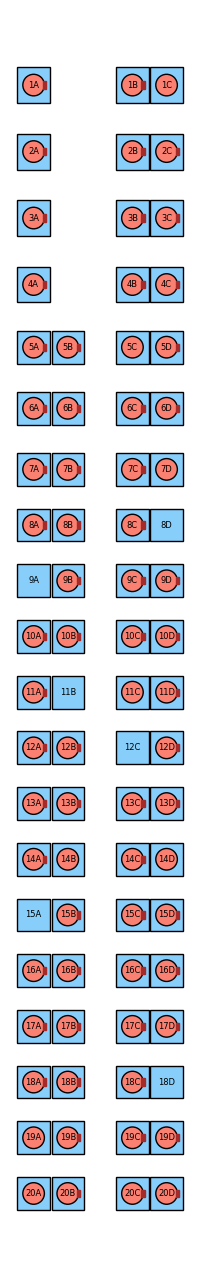

In [18]:
random_board = RandomBoarding(num_of_passengers, plane, Passenger)
random_board.animate()

In [21]:
def run_simulation(boarding):
    steps = 0
    while not boarding.all_passengers_seated():
        boarding.step()
        steps += 1
    print(f"Plane was boarded in {steps} steps.")

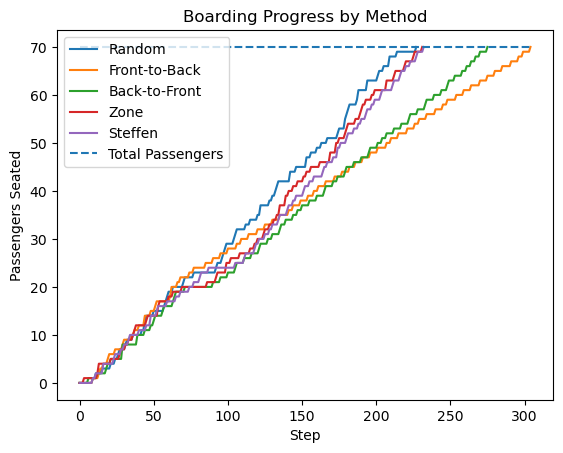

In [28]:
# boarding progress for each method

import matplotlib.pyplot as plt

# Define the boarding methods
methods = {
    'Random': RandomBoarding,
    'Front-to-Back': FrontToBackBoarding,
    'Back-to-Front': BackToFrontBoarding,
    'Zone': ZoneBoarding,
    'Steffen': SteffenBoarding
}

total_passengers = int(num_of_passengers)

# Compute seated‐count history for each method
seating_progress = {}
for name, Method in methods.items():
    # Reinitialize plane and boarding
    plane_sim = Plane(
        seat_params_info(df, plane_choice),
        num_of_seats_info(df, plane_choice),
        seat_arrange_info(df, plane_choice)
    )
    boarding_sim = Method(total_passengers, plane_sim, Passenger)
    
    counts = [sum(p.status == "seated" for p in boarding_sim.passengers)]
    while not boarding_sim.all_passengers_seated():
        boarding_sim.step()
        counts.append(sum(p.status == "seated" for p in boarding_sim.passengers))
    seating_progress[name] = counts

# Plotting
plt.figure()
for name, counts in seating_progress.items():
    plt.plot(range(len(counts)), counts, label=name)

# Dotted horizontal line at total passengers
max_steps = max(len(c) for c in seating_progress.values()) - 1
plt.hlines(total_passengers, xmin=0, xmax=max_steps, linestyle='--', label='Total Passengers')

plt.xlabel('Step')
plt.ylabel('Passengers Seated')
plt.title('Boarding Progress by Method')
plt.legend()
plt.show()


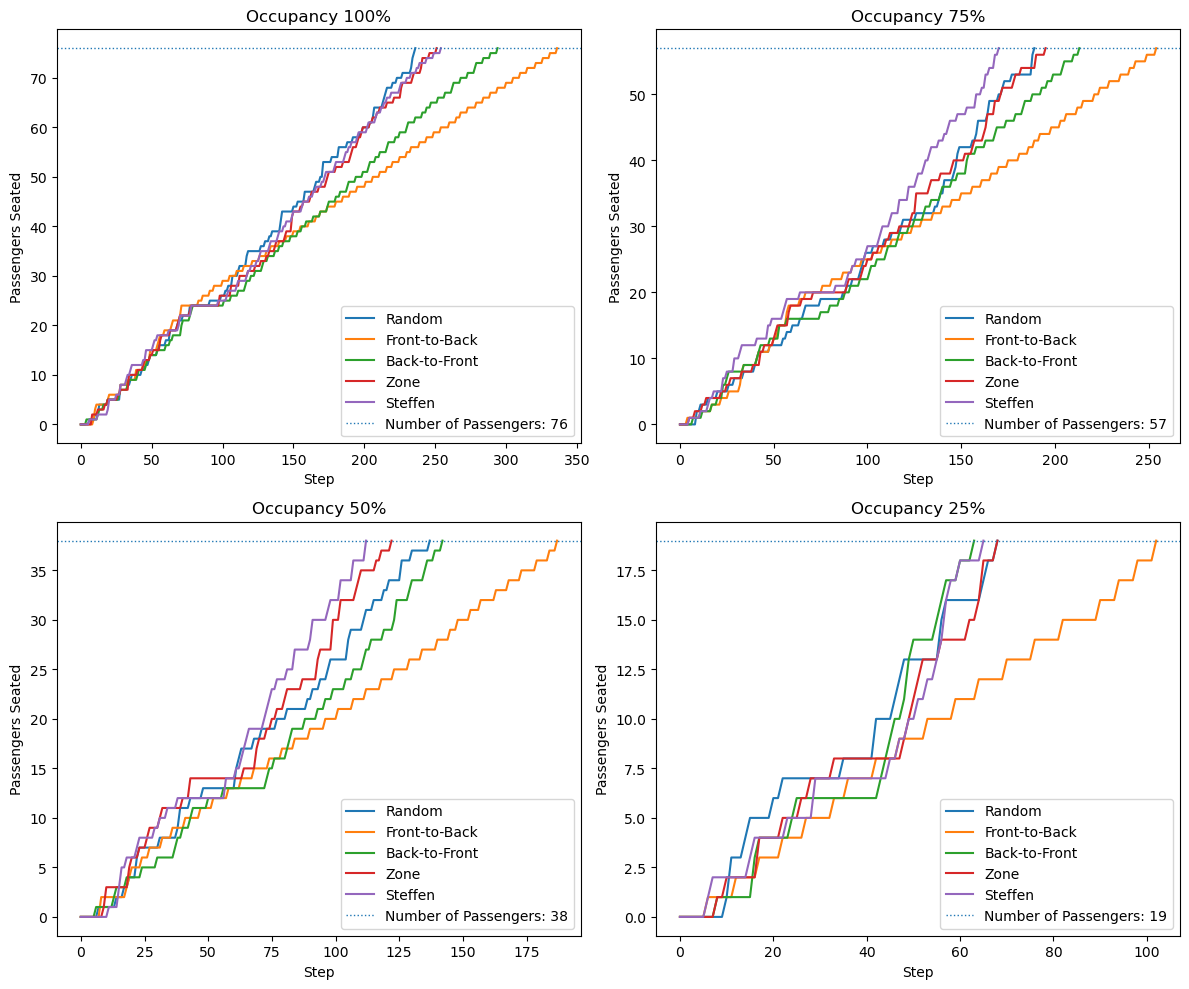

In [31]:
# plot seating progression for different occupancy levels
import matplotlib.pyplot as plt

methods = {
    'Random': RandomBoarding,
    'Front-to-Back': FrontToBackBoarding,
    'Back-to-Front': BackToFrontBoarding,
    'Zone': ZoneBoarding,
    'Steffen': SteffenBoarding
}

# Occupancy settings and labels
occupancy_levels = [1.0, 0.75, 0.5, 0.25]
occupancy_labels = ['100%', '75%', '50%', '25%']

# Total seats on the plane
total_seats = len(Plane(
    seat_params_info(df, plane_choice),
    num_of_seats_info(df, plane_choice),
    seat_arrange_info(df, plane_choice)
).seats)

# Create a 2×2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, occ, label in zip(axes.flatten(), occupancy_levels, occupancy_labels):
    num_passengers = int(total_seats * occ)
    
    # Plot each method's seating curve
    for name, Method in methods.items():
        # Reset plane & boarding simulation
        plane_sim = Plane(
            seat_params_info(df, plane_choice),
            num_of_seats_info(df, plane_choice),
            seat_arrange_info(df, plane_choice)
        )
        boarding_sim = Method(num_passengers, plane_sim, Passenger)

        # Track seated count over steps
        seated_counts = [sum(p.status == "seated" for p in boarding_sim.passengers)]
        while not boarding_sim.all_passengers_seated():
            boarding_sim.step()
            seated_counts.append(sum(p.status == "seated" for p in boarding_sim.passengers))

        ax.plot(range(len(seated_counts)), seated_counts, label=name)
    
    # Add dotted horizontal line with dynamic legend label
    ax.axhline(
        num_passengers,
        linestyle=':',
        linewidth=1,
        label=f'Number of Passengers: {num_passengers}'
    )
    
    ax.set_title(f'Occupancy {label}')
    ax.set_xlabel('Step')
    ax.set_ylabel('Passengers Seated')
    ax.legend()

plt.tight_layout()
plt.show()